In [1]:
import os

try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from src.figures import save_figure

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

from src.data_loader import _load_disaster_data

df = _load_disaster_data(BASE)
    
figure_path = os.path.join(BASE, '05_figures')
os.makedirs(figure_path, exist_ok=True)

# VL 05: Decision Trees

**Fig. 5.1** Regions motivation

Saved Fig. 5.1 -> 05_figures/5.1_regions_motivation/5.1_regions_motivation.pdf


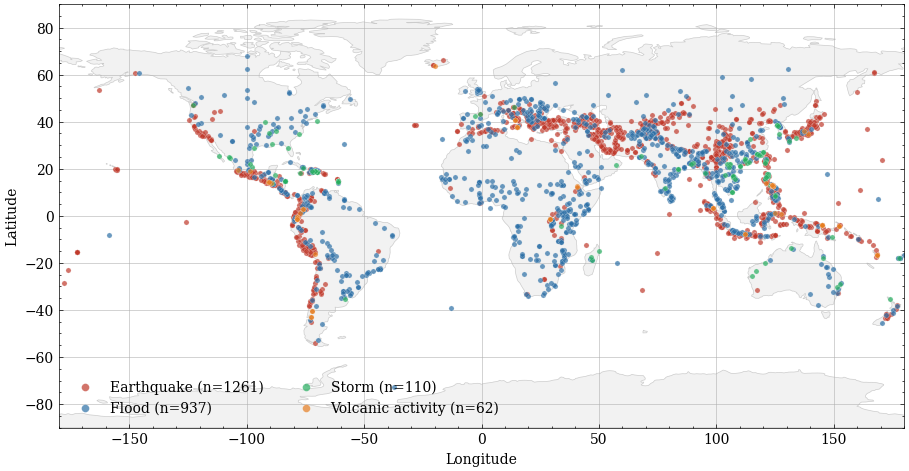

In [2]:
geo = df.copy()
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo[geo['Latitude'].between(-90, 90) & geo['Longitude'].between(-180, 180)]

types = ['Earthquake', 'Flood', 'Storm', 'Volcanic activity']
geo = geo[geo['Disaster Type'].isin(types)]
colors = {'Earthquake': '#C0392B', 'Volcanic activity': '#E67E22',
          'Flood': '#2C6FA6', 'Storm': '#27AE60'}

fig, ax = plt.subplots(figsize=(11, 5.5))

try:
    import geopandas as gpd
    from geodatasets import get_path
    gpd.read_file(get_path('naturalearth.land')).plot(
        ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.5, zorder=0)
except Exception:
    pass

for t in types:
    s = geo[geo['Disaster Type'] == t]
    ax.scatter(s['Longitude'], s['Latitude'], s=14, alpha=0.7, color=colors[t],
               edgecolors='white', linewidth=0.2, label=f'{t} (n={len(s)})', zorder=2)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', markerscale=1.5, framealpha=0.9, ncol=2)
save_figure(5, 1, 'regions_motivation')
plt.show()

**Fig. 5.2** Tree regions

Saved Fig. 5.2 -> 05_figures/5.2_tree_regions/5.2_tree_regions_depth5.pdf


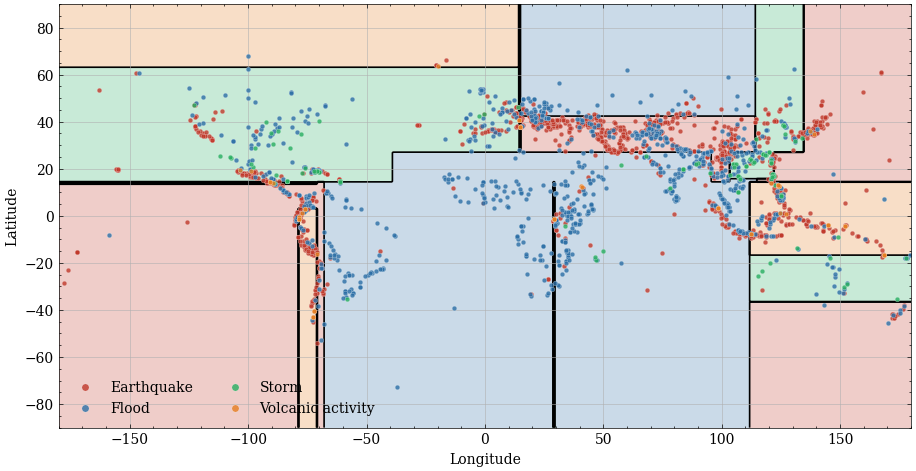

In [3]:
max_depth = 5

geo = df.copy()
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo[geo['Latitude'].between(-90, 90) & geo['Longitude'].between(-180, 180)]
types = ['Earthquake', 'Flood', 'Storm', 'Volcanic activity']
geo = geo[geo['Disaster Type'].isin(types)]
colmap = {'Earthquake': '#C0392B', 'Flood': '#2C6FA6', 'Storm': '#27AE60', 'Volcanic activity': '#E67E22'}

X = geo[['Longitude', 'Latitude']].values
y = geo['Disaster Type'].astype(str).values

clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0, 
                             class_weight='balanced'
                             ).fit(X, y)
classes = clf.classes_
code_of = {c: i for i, c in enumerate(classes)}

xx, yy = np.meshgrid(np.linspace(-180, 180, 600), np.linspace(-90, 90, 400))
Z = np.vectorize(code_of.get)(clf.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.contourf(xx, yy, Z, levels=np.arange(-0.5, len(classes) + 0.5),
            colors=[colmap[c] for c in classes], alpha=0.25, zorder=0)
ax.contour(xx, yy, Z, levels=np.arange(0.5, len(classes)),
           colors='black', linewidths=1.2, zorder=1)               
for c in classes:
    s = geo[geo['Disaster Type'] == c]
    ax.scatter(s['Longitude'], s['Latitude'], s=12, alpha=0.8, color=colmap[c],
               edgecolors='white', linewidth=0.2, label=c, zorder=2)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', markerscale=1.5, framealpha=0.9, ncol=2)
save_figure(5, 2, 'tree_regions', variant=f'depth{max_depth}')
plt.show()

**Fig. 5.3** Tree diagram

Saved Fig. 5.3 -> 05_figures/5.3_tree_diagram/5.3_tree_diagram_depth3.pdf


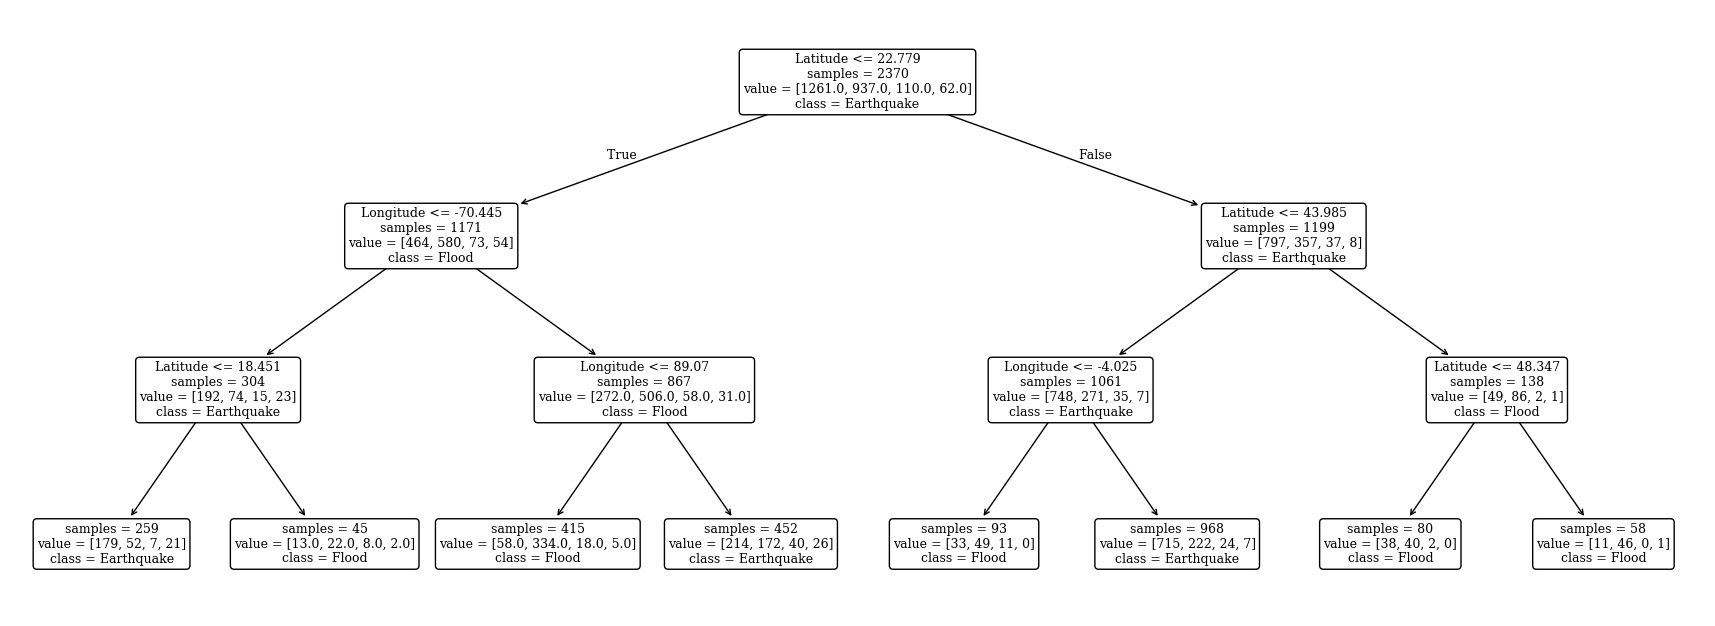

In [4]:
max_depth = 3
clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0).fit(X, y)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    clf,
    feature_names=['Longitude', 'Latitude'],
    class_names=clf.classes_,
    filled=False,        
    rounded=True,
    impurity=False,      
    fontsize=9,
    ax=ax,
)
save_figure(5, 3, 'tree_diagram', variant=f'depth{max_depth}')
plt.show()

**Fig. 5.3** Tree diagram (compact)

Saved Fig. 5.3 -> 05_figures/5.3_tree_diagram/5.3_tree_diagram_depth3_small.pdf


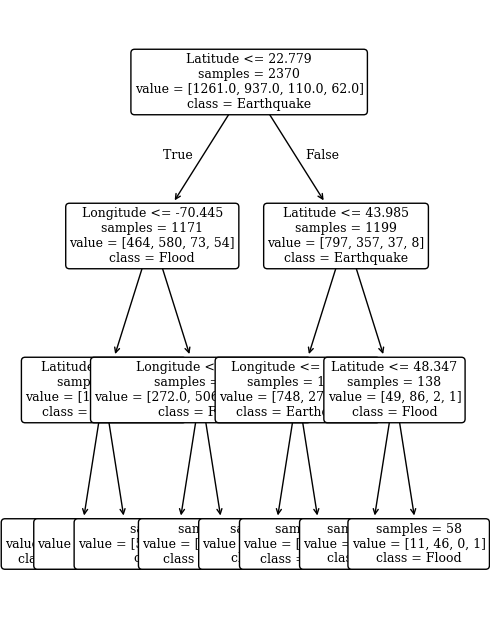

In [5]:
max_depth = 3
clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0).fit(X, y)

fig, ax = plt.subplots(figsize=(5, 8))
plot_tree(
    clf,
    feature_names=['Longitude', 'Latitude'],
    class_names=clf.classes_,
    filled=False,        
    rounded=True,
    impurity=False,      
    fontsize=9,
    ax=ax,
)
save_figure(5, 3, 'tree_diagram', variant=f'depth{max_depth}_small')
plt.show()

**Fig. 5.3** Tree diagram (unpruned)

Saved Fig. 5.3 -> 05_figures/5.3_tree_diagram/5.3_tree_diagram_depth_none.pdf


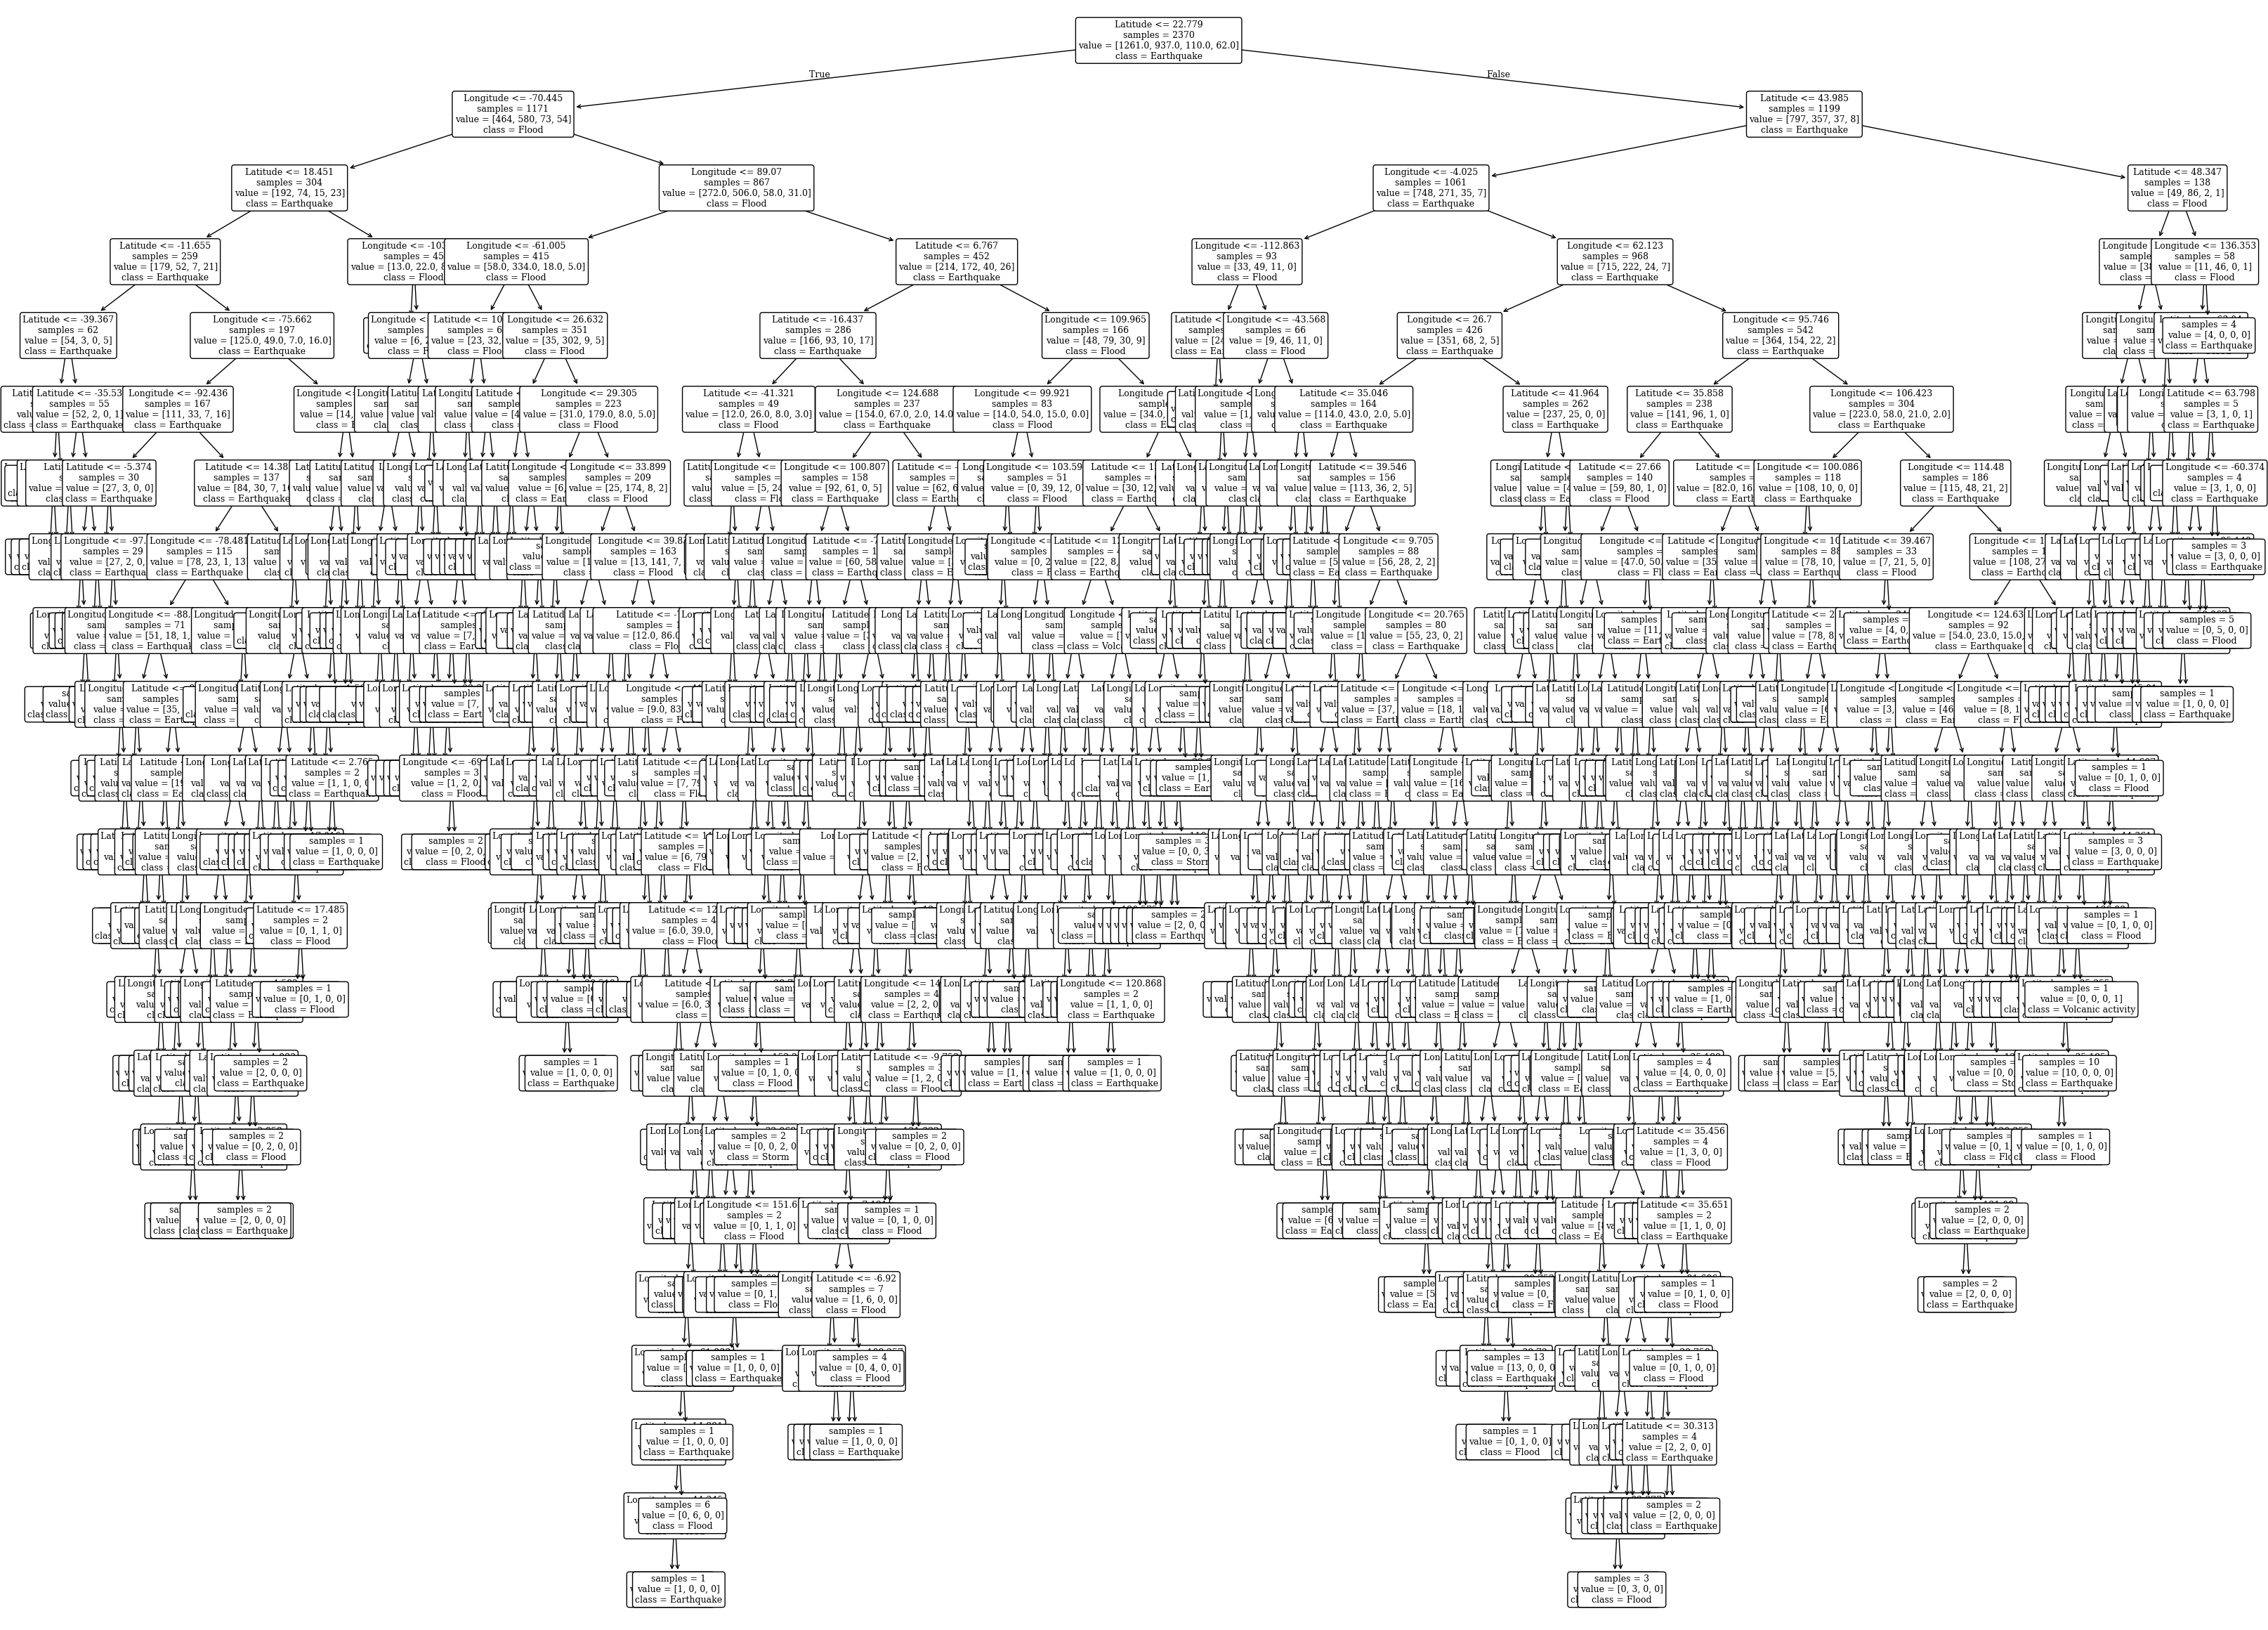

In [6]:
clf = DecisionTreeClassifier(random_state=0).fit(X, y)

fig, ax = plt.subplots(figsize=(40, 30))
plot_tree(
    clf,
    feature_names=['Longitude', 'Latitude'],
    class_names=clf.classes_,
    filled=False,        
    rounded=True,
    impurity=False,    
    fontsize=9,
    ax=ax,
)
save_figure(5, 3, 'tree_diagram', variant='depth_none')
plt.show()

**Fig. 5.4** Overfitting

Saved Fig. 5.4 -> 05_figures/5.4_overfitting/5.4_overfitting.pdf


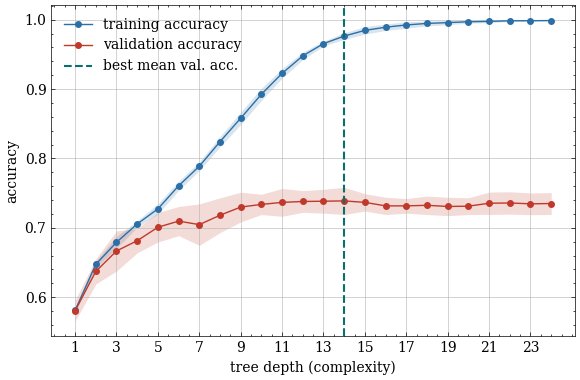

In [7]:
geo = df.copy()
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo[geo['Latitude'].between(-90, 90) & geo['Longitude'].between(-180, 180)]
types = ['Earthquake', 'Flood', 'Storm', 'Volcanic activity']
geo = geo[geo['Disaster Type'].isin(types)]

X = geo[['Longitude', 'Latitude']].values
y = geo['Disaster Type'].astype(str).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

depths = range(1, 25)
train_mean, train_std = [], []
val_mean, val_std = [], []
for d in depths:
    scores = cross_validate(
        DecisionTreeClassifier(max_depth=d, random_state=0),
        X,
        y,
        cv=cv,
        scoring='accuracy',
        return_train_score=True,
    )
    train_mean.append(scores['train_score'].mean())
    train_std.append(scores['train_score'].std())
    val_mean.append(scores['test_score'].mean())
    val_std.append(scores['test_score'].std())

best_d = list(depths)[int(np.argmax(val_mean))]   

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(depths), train_mean, '-o', ms=4, color='#2C6FA6', label='training accuracy')
ax.fill_between(list(depths), np.array(train_mean) - np.array(train_std), np.array(train_mean) + np.array(train_std),
                color='#2C6FA6', alpha=0.18, linewidth=0)
ax.plot(list(depths), val_mean, '-o', ms=4, color='#C0392B', label='validation accuracy')
ax.fill_between(list(depths), np.array(val_mean) - np.array(val_std), np.array(val_mean) + np.array(val_std),
                color='#C0392B', alpha=0.18, linewidth=0)
ax.axvline(best_d, color='#0B6E6E', ls='--', lw=1.5,
           label=f'best mean val. acc. ')
ax.set_xlabel('tree depth (complexity)')
ax.set_ylabel('accuracy')
ax.set_xticks(range(1, 25, 2))
ax.legend(loc='upper left')
plt.tight_layout()
save_figure(5, 4, 'overfitting', dpi=140)
plt.show()

**Fig. 5.5** Pre-pruning validation curves

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_max_depth.pdf


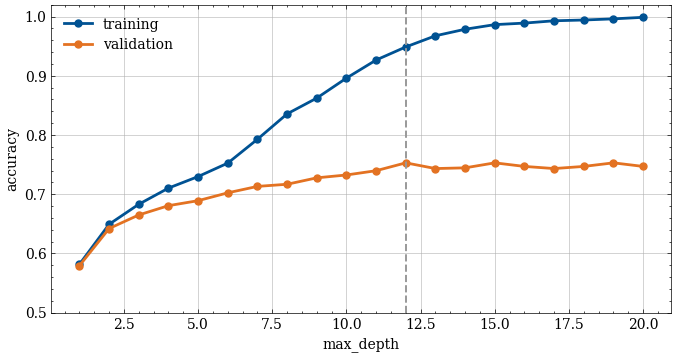

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_max_leaf_nodes.pdf


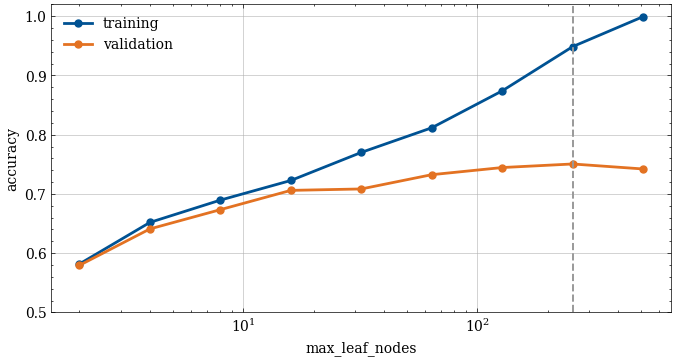

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_min_samples_split.pdf


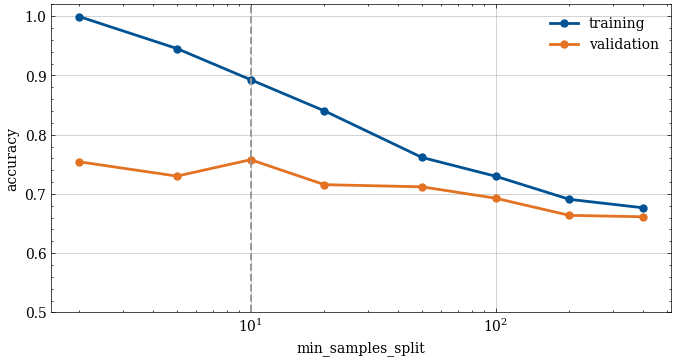

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_min_samples_leaf.pdf


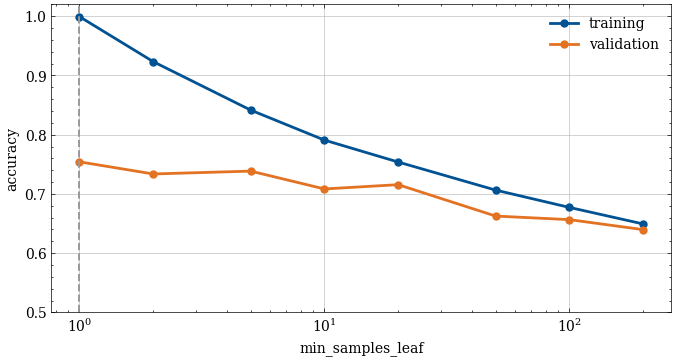

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_min_weight_fraction_leaf.pdf


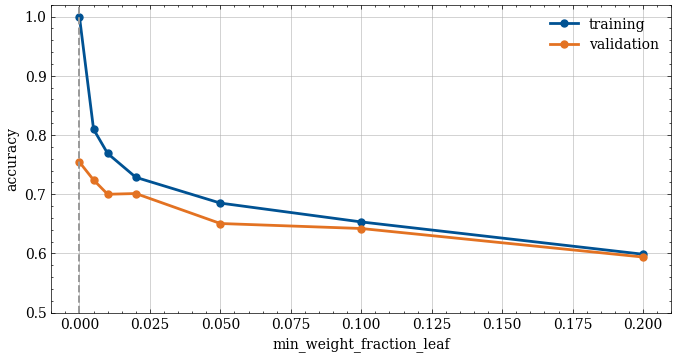

Saved Fig. 5.5 -> 05_figures/5.5_prepruning/5.5_prepruning_min_impurity_decrease.pdf


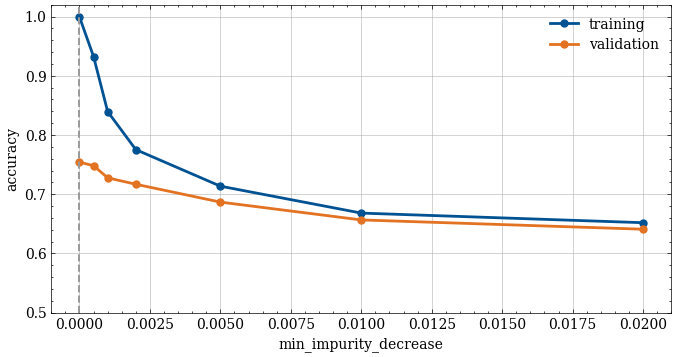

In [8]:
# TUM palette
TRAIN, VAL, OPT = '#005293', '#E37222', '#999999'

geo = df.copy()
geo['Latitude']  = pd.to_numeric(geo['Latitude'],  errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo[geo['Latitude'].between(-90, 90) & geo['Longitude'].between(-180, 180)]
geo = geo[geo['Disaster Type'].isin(['Earthquake', 'Flood', 'Storm', 'Volcanic activity'])]

X = geo[['Longitude', 'Latitude']].values
y = geo['Disaster Type'].astype(str).values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.35, random_state=0, stratify=y)


def validation_curve(param, values, logx=False):
    """Sweep one pre-pruning parameter; plot train vs. validation accuracy."""
    train_acc, val_acc = [], []
    for v in values:
        clf = DecisionTreeClassifier(random_state=0, **{param: v}).fit(X_tr, y_tr)
        train_acc.append(clf.score(X_tr, y_tr))
        val_acc.append(clf.score(X_te, y_te))
    best = values[int(np.argmax(val_acc))]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(values, train_acc, '-o', ms=5, lw=2, color=TRAIN, label='training')
    ax.plot(values, val_acc,   '-o', ms=5, lw=2, color=VAL,   label='validation')
    ax.axvline(best, color=OPT, ls='--', lw=1.4)               
    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(param)
    ax.set_ylabel('accuracy')
    ax.set_ylim(0.5, 1.02)
    ax.legend(loc='best')
    save_figure(5, 5, 'prepruning', variant=param, dpi=140)
    plt.show()


validation_curve('max_depth',                list(range(1, 21)))
validation_curve('max_leaf_nodes',           [2, 4, 8, 16, 32, 64, 128, 256, 512],  logx=True)
validation_curve('min_samples_split',        [2, 5, 10, 20, 50, 100, 200, 400],     logx=True)
validation_curve('min_samples_leaf',         [1, 2, 5, 10, 20, 50, 100, 200],       logx=True)
validation_curve('min_weight_fraction_leaf', [0.0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2])
validation_curve('min_impurity_decrease',    [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02])

**Fig. 5.6** Post-pruning

Saved Fig. 5.6 -> 05_figures/5.6_postpruning/5.6_postpruning.pdf


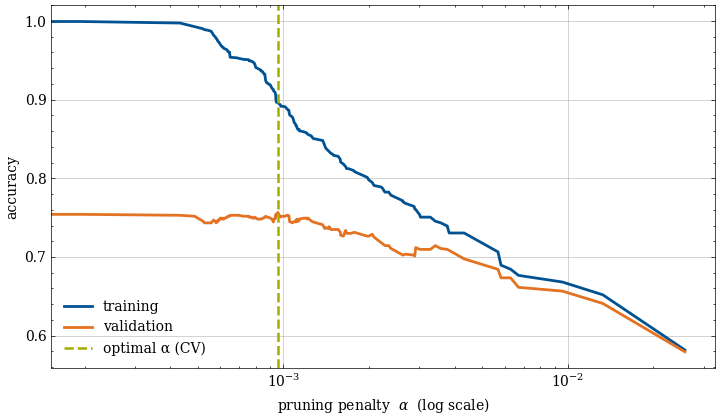

In [9]:
TRAIN, VAL, OPT = '#005293', '#E37222', '#A2AD00'

base = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)
alphas = base.cost_complexity_pruning_path(X_tr, y_tr).ccp_alphas[:-1]   # candidate αs

train_acc, val_acc, n_leaves = [], [], []
for a in alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X_tr, y_tr)
    train_acc.append(clf.score(X_tr, y_tr)); val_acc.append(clf.score(X_te, y_te))
    n_leaves.append(clf.get_n_leaves())
best = int(np.argmax(val_acc))

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(alphas, train_acc, color=TRAIN, lw=2, label='training')
ax.plot(alphas, val_acc,   color=VAL,   lw=2, label='validation')
ax.axvline(alphas[best], color=OPT, ls='--', lw=1.8, label='optimal α (CV)')
ax.set_xscale('log'); ax.set_xlabel(r'pruning penalty  $\alpha$  (log scale)'); ax.set_ylabel('accuracy')
ax.legend(loc='lower left')
plt.tight_layout()
save_figure(5, 6, 'postpruning', dpi=140)
plt.show()

**Fig. 5.7** Bagging

Saved Fig. 5.7 -> 05_figures/5.7_bagging/5.7_bagging_bootstrap.pdf


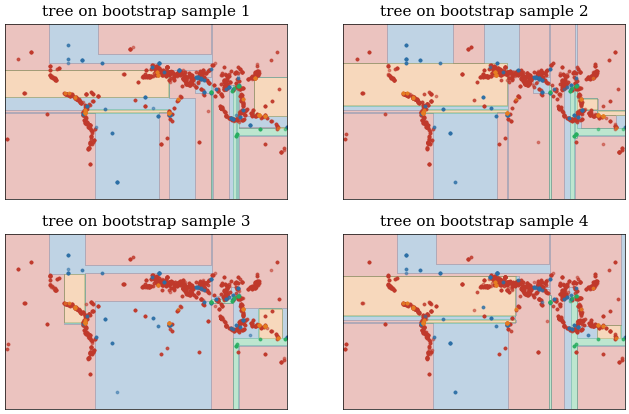

Saved Fig. 5.7 -> 05_figures/5.7_bagging/5.7_bagging_bagged.pdf


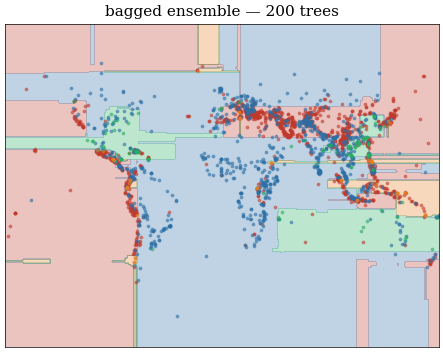

In [10]:
geo = df.copy()
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')
geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo = geo[geo['Latitude'].between(-90, 90) & geo['Longitude'].between(-180, 180)]
types = ['Earthquake', 'Flood', 'Storm', 'Volcanic activity']
geo = geo[geo['Disaster Type'].isin(types)]
colmap = {'Earthquake': '#C0392B', 'Flood': '#2C6FA6', 'Storm': '#27AE60', 'Volcanic activity': '#E67E22'}

X = geo[['Longitude', 'Latitude']].values
y = geo['Disaster Type'].astype(str).values

xx, yy = np.meshgrid(np.linspace(-180, 180, 400), np.linspace(-90, 90, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
DEPTH = 6

def boundary(ax, clf, title, Xs=None, ys=None):
    if Xs is None:                      
        Xs, ys = X, y
    classes = clf.classes_
    code = {c: i for i, c in enumerate(classes)}
    Z = np.vectorize(code.get)(clf.predict(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.arange(-0.5, len(classes) + 0.5),
                colors=[colmap[c] for c in classes], alpha=0.30)
    for c in types:
        m = ys == c
        ax.scatter(Xs[m, 0], Xs[m, 1], s=3, color=colmap[c], alpha=0.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=11)

rng = np.random.default_rng(1); n = len(X)
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for k, ax in enumerate(axes.ravel()):
    idx = rng.integers(0, n//3, n)
    t = DecisionTreeClassifier(max_depth=DEPTH, class_weight='balanced',
                               random_state=0).fit(X[idx], y[idx])
    boundary(ax, t, f'tree on bootstrap sample {k+1}', Xs=X[idx], ys=y[idx])
save_figure(5, 7, 'bagging', variant='bootstrap', dpi=140)
plt.show()

bag = BaggingClassifier(
    DecisionTreeClassifier(max_depth=DEPTH, class_weight='balanced',
                           ),
    n_estimators=100, random_state=0, oob_score=True).fit(X, y)
fig, ax = plt.subplots(figsize=(5.6, 4.2))
boundary(ax, bag, 'bagged ensemble — 200 trees')
save_figure(5, 7, 'bagging', variant='bagged', dpi=140)
plt.show()

**Fig. 5.8** Boosting

Saved Fig. 5.8 -> 05_figures/5.8_boosting/5.8_boosting_stages.pdf


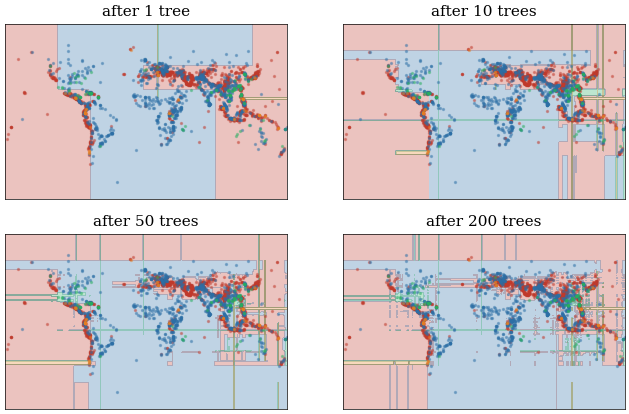

Saved Fig. 5.8 -> 05_figures/5.8_boosting/5.8_boosting_accuracy.pdf


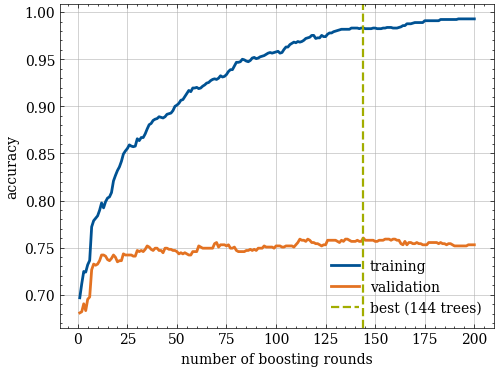

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.35, random_state=0, stratify=y)
N = 200
gb = GradientBoostingClassifier(n_estimators=N, max_depth=3, learning_rate=0.3, random_state=0).fit(X_tr, y_tr)
classes = gb.classes_
code = {c: i for i, c in enumerate(classes)}

want = [1, 10, 50, 200]
gp = {}
for i, pred in enumerate(gb.staged_predict(grid), start=1):
    if i in want:
        gp[i] = pred

def panel(ax, pred, title):
    Z = np.vectorize(code.get)(pred).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.arange(-0.5, len(classes) + 0.5),
                colors=[colmap[c] for c in classes], alpha=0.30)
    for c in types:
        m = y == c
        ax.scatter(X[m, 0], X[m, 1], s=2, color=colmap[c], alpha=0.4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for ax, k in zip(axes.ravel(), want):
    panel(ax, gp[k], f'after {k} tree' + ('s' if k > 1 else ''))
save_figure(5, 8, 'boosting', variant='stages', dpi=140)
plt.show()

tr = [accuracy_score(y_tr, p) for p in gb.staged_predict(X_tr)]
te = [accuracy_score(y_te, p) for p in gb.staged_predict(X_te)]
best = int(np.argmax(te)) + 1
fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.plot(range(1, N+1), tr, color='#005293', lw=2, label='training')
ax.plot(range(1, N+1), te, color='#E37222', lw=2, label='validation')
ax.axvline(best, color='#A2AD00', ls='--', lw=1.6, label=f'best ({best} trees)')
ax.set_xlabel('number of boosting rounds')
ax.set_ylabel('accuracy')
ax.legend(loc='lower right')
save_figure(5, 8, 'boosting', variant='accuracy', dpi=140)
plt.show()